<a href="https://colab.research.google.com/github/TommyLl1/ESTR2020/blob/main/ESTR2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [361]:
import pandas as pd
import numpy as np
import arviz as az
from scipy.stats import norm
from scipy.stats import gamma
from scipy.stats import loggamma
from scipy.special import log_expit
from scipy.special import expit
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [367]:
def print_performance_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("-" * 30)
    print(f"Performance Metrics:")
    print(f"Accuracy:  {np.mean(y_true == y_pred):.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("-" * 30)
    print("Confusion Matrix:")
    print(cm)
    print("-" * 30)

    return precision, recall, f1

In [368]:
y_pred = pred_result["pred_class"]

precision, recall, f1 = print_performance_metrics(y_test, y_pred)

------------------------------
Performance Metrics:
Accuracy:  0.6300
Precision: 0.7458
Recall:    0.6667
F1-score:  0.7040
------------------------------
Confusion Matrix:
[[19 15]
 [22 44]]
------------------------------


In [332]:
def load_data():
    df = pd.read_csv("/regression.csv")

    X = df.iloc[:,:-1].values
    y = df.iloc[:,-1].values
    return X, y

In [333]:
X, y = load_data()

In [334]:
X_test = X[-100:,:]
y_test = y[-100:]
X_train = X[:-100:,:]
y_train = y[:-100:]

In [335]:
def unnormalized_full_log_posterior(X, y, U, beta):
    bias_term = np.matmul(X, U) * beta * np.sum(U)

    # Get log-probabilities directly
    log_p = log_expit(bias_term)
    log_1_minus_p = log_expit(-bias_term)

    # Use the log-probabilities directly in the dot product
    log_lik = np.dot(y, log_p) + np.dot((1 - y), log_1_minus_p)

    log_prior_beta = np.log(np.maximum(beta, 1e-12)) - 2 * beta
    log_prior_U = -np.sum(np.abs(U))

    return log_lik + log_prior_beta + log_prior_U


In [337]:
def MH_1step_U(X, y, U_old, beta, i, step):
  U_proposal = np.copy(U_old)
  U_proposal[i] = norm.rvs(loc=U_old[i], scale=step)

  log_acceptance = unnormalized_full_log_posterior(X, y, U_proposal, beta) \
            - unnormalized_full_log_posterior(X, y, U_old, beta)

  if np.log(np.random.uniform(0, 1)) < log_acceptance:
    return U_proposal, 1
  else:
    return U_old, 0

In [338]:
# def MH_step_U_vectorized(X, y, U_old, beta, step):
#     U_proposal = U_old + norm.rvs(scale=step, size=U_old.shape)
#     log_acc = unnormalized_full_log_posterior(X, y, U_proposal, beta) - \
#               unnormalized_full_log_posterior(X, y, U_old, beta)
#     if np.log(np.random.rand()) < log_acc:
#         return U_proposal, 1
#     return U_old, 0

In [339]:
def MH_1step_beta_logscale(X, y, U, beta_old, step):
    """
    Metropolis update for beta on log scale:
        eta = log(beta)
        eta_proposal ~ N(eta_old, step^2)
        beta_proposal = exp(eta_proposal)
    """
    eta_old = np.log(beta_old)
    eta_proposal = norm.rvs(loc=eta_old, scale=step)
    beta_proposal = np.exp(eta_proposal)

    # log posterior in eta-space = log posterior in beta-space + log Jacobian
    log_post_old = unnormalized_full_log_posterior(X, y, U, beta_old) + eta_old
    log_post_new = unnormalized_full_log_posterior(X, y, U, beta_proposal) + eta_proposal

    log_acceptance = log_post_new - log_post_old

    if np.log(np.random.uniform(0, 1)) < log_acceptance:
        return beta_proposal, 1
    else:
        return beta_old, 0

In [340]:
# def MH_within_Gibbs(X, y, J, steps):
#   U = np.full((J+1, 100), np.nan)
#   beta = np.full(J+1, np.nan)
#   log_post_trace = np.full(J+1, np.nan)
#   U[0,:] = np.array(norm.rvs(loc=0, scale=0.1, size=100))
#   U[0,:] = abs(U[0,:])
#   beta[0] = gamma.rvs(a = 1, scale = 1)

#   u_accept = 0
#   beta_accept = 0
#   log_post_trace[0] = unnormalized_full_log_posterior(X, y, U[0,:], beta[0])
#   for j in range(1, (J+1)):
#     U_temp = np.copy(U[j-1,:])
#     # for i in range(100):
#     U_temp, temp = MH_step_U_vectorized(X, y, U_temp, beta[j-1], steps[0])
#     u_accept += temp
#     U[j,:] = U_temp
#     beta[j], temp = MH_1step_beta_logscale(X, y, U_temp, beta[j-1], steps[1])
#     beta_accept += temp
#     log_post_trace[j] = unnormalized_full_log_posterior(X, y, U[j,:], beta[j])
#     if j % 1000 == 0:
#       print(f"Iteration {j}/{J} completed.")
#   # print(f"U Acceptance Rate: {u_accept / (J * 100):.2%}")
#   print(f"U Acceptance Rate: {u_accept / (J):.2%}")
#   print(f"Beta Acceptance Rate: {beta_accept / J:.2%}")
#   return U, beta, log_post_trace


In [341]:
def MH_within_Gibbs(X, y, J, steps):
  U = np.full((J+1, 100), np.nan)
  beta = np.full(J+1, np.nan)
  log_post_trace = np.full(J+1, np.nan)
  U[0,:] = np.array(norm.rvs(loc=0, scale=0.1, size=100))
  U[0,:] = abs(U[0,:])
  beta[0] = gamma.rvs(a = 1, scale = 1)

  u_accept = 0
  beta_accept = 0
  log_post_trace[0] = unnormalized_full_log_posterior(X, y, U[0,:], beta[0])
  for j in range(1, (J+1)):
    U_temp = np.copy(U[j-1,:])
    for i in range(100):
      U_temp, temp = MH_1step_U(X, y, U_temp, beta[j-1], i, steps[0])
      u_accept += temp
    U[j,:] = U_temp
    beta[j], temp = MH_1step_beta_logscale(X, y, U_temp, beta[j-1], steps[1])
    beta_accept += temp
    log_post_trace[j] = unnormalized_full_log_posterior(X, y, U[j,:], beta[j])
    if j % 1000 == 0:
      print(f"Iteration {j}/{J} completed.")
  print(f"U Acceptance Rate: {u_accept / (J * 100):.2%}")
  # print(f"U Acceptance Rate: {u_accept / (J):.2%}")
  print(f"Beta Acceptance Rate: {beta_accept / J:.2%}")
  return U, beta, log_post_trace

In [342]:
np.random.seed(4416)
U_c1, beta_c1, log_post_1 = MH_within_Gibbs(X, y, 20000, [0.05, 0.3])
U_c2, beta_c2, log_post_2 = MH_within_Gibbs(X, y, 20000, [0.05, 0.3])

Iteration 1000/20000 completed.
Iteration 2000/20000 completed.
Iteration 3000/20000 completed.
Iteration 4000/20000 completed.
Iteration 5000/20000 completed.
Iteration 6000/20000 completed.
Iteration 7000/20000 completed.
Iteration 8000/20000 completed.
Iteration 9000/20000 completed.
Iteration 10000/20000 completed.
Iteration 11000/20000 completed.
Iteration 12000/20000 completed.
Iteration 13000/20000 completed.
Iteration 14000/20000 completed.
Iteration 15000/20000 completed.
Iteration 16000/20000 completed.
Iteration 17000/20000 completed.
Iteration 18000/20000 completed.
Iteration 19000/20000 completed.
Iteration 20000/20000 completed.
U Acceptance Rate: 39.67%
Beta Acceptance Rate: 60.29%
Iteration 1000/20000 completed.
Iteration 2000/20000 completed.
Iteration 3000/20000 completed.
Iteration 4000/20000 completed.
Iteration 5000/20000 completed.
Iteration 6000/20000 completed.
Iteration 7000/20000 completed.
Iteration 8000/20000 completed.
Iteration 9000/20000 completed.
Iterat

In [343]:
# remove Burn-in
burn = 10000
thin = 4
log_post_trace_1 = log_post_1[burn::thin]
log_post_trace_2 = log_post_2[burn::thin]
posterior_dict = {
    "beta": np.stack([beta_c1[burn::thin], beta_c2[burn::thin]]), # Shape: (2, 2500)
    "U": np.stack([U_c1[burn::thin], U_c2[burn::thin]])          # Shape: (2, 2500, 100)
}

dataset = az.convert_to_inference_data(posterior_dict)
summary = az.summary(dataset)

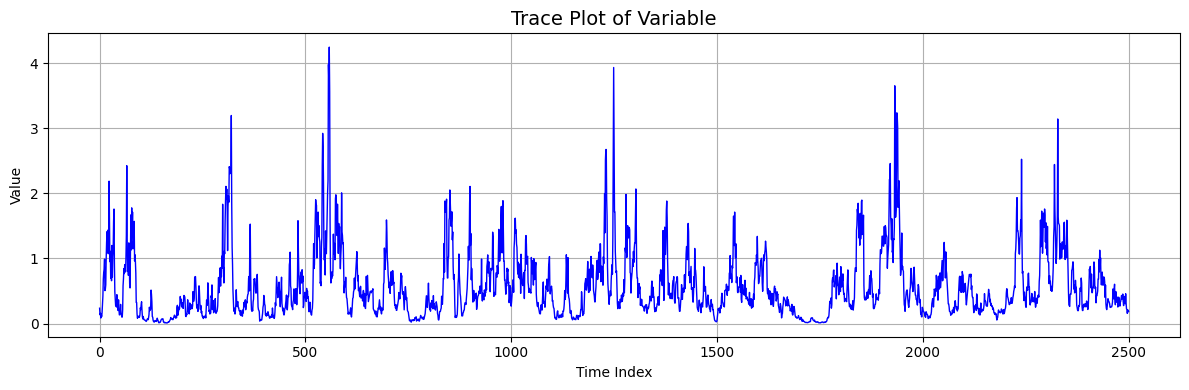

<Figure size 800x600 with 0 Axes>

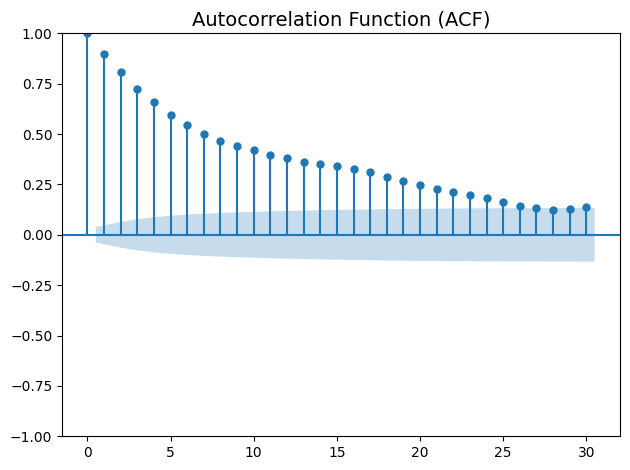

In [358]:
# Plot Trace Plot
plt.figure(figsize=(12, 4))
plt.plot(posterior_dict["beta"][0,:], color='blue', linewidth=1)
plt.title("Trace Plot of Variable", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.savefig("beta_TracePlot")
plt.show()

# Plot ACF
plt.figure(figsize=(8, 6))
plot_acf(posterior_dict["beta"][0,:], lags=30, alpha=0.05)  # alpha=0.05 adds confidence intervals
plt.title("Autocorrelation Function (ACF)", fontsize=14)
plt.tight_layout()
plt.savefig("beta_ACF")
plt.show()


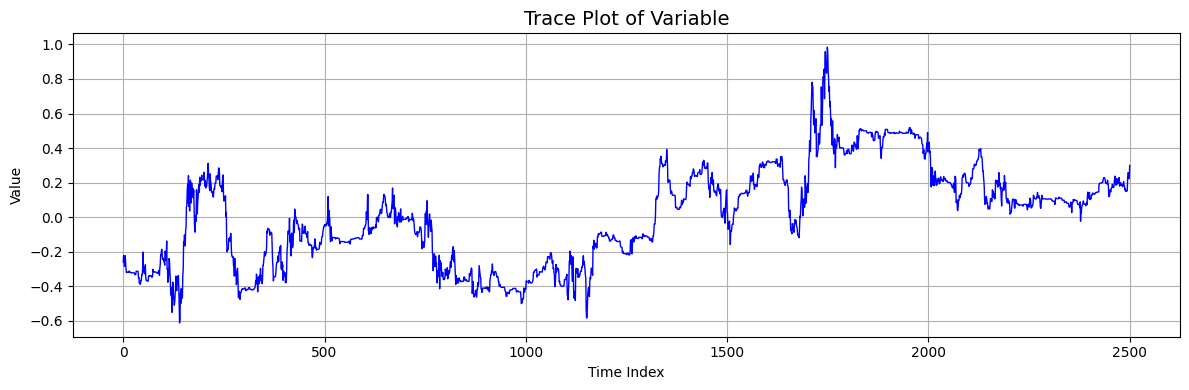

<Figure size 800x600 with 0 Axes>

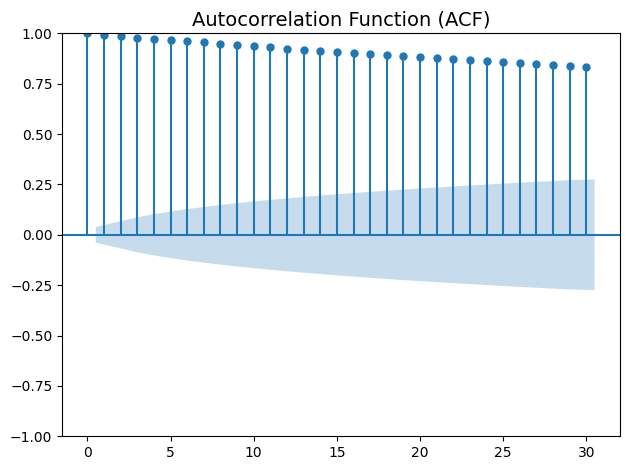

In [359]:
# Plot Trace Plot
i=0
j=1
plt.figure(figsize=(12, 4))
plt.plot(posterior_dict["U"][i,:,j], color='blue', linewidth=1)
plt.title("Trace Plot of Variable", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.savefig("U_TracePlot")
plt.show()

# Plot ACF
plt.figure(figsize=(8, 6))
plot_acf(posterior_dict["U"][i,:,j], lags=30, alpha=0.05)  # alpha=0.05 adds confidence intervals
plt.title("Autocorrelation Function (ACF)", fontsize=14)
plt.tight_layout()
plt.savefig("U_ACF")
plt.show()


Summary of all 101 variables:
       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
U[0]  0.431  0.668  -0.502    1.652      0.351    0.111       4.0      23.0   
U[1] -0.021  0.473  -0.893    0.993      0.223    0.117       4.0      12.0   
U[2] -1.193  2.288  -4.354    1.647      1.560    0.189       3.0      14.0   
U[3]  0.577  0.813  -0.552    2.094      0.331    0.112       6.0      15.0   
U[4] -0.469  0.433  -1.246    0.281      0.172    0.040       7.0      54.0   

      r_hat  
U[0]   1.46  
U[1]   1.38  
U[2]   1.96  
U[3]   1.27  
U[4]   1.25  

Variables with R-hat > 1.1: 98
Variables with Bulk-ESS < 100: 100


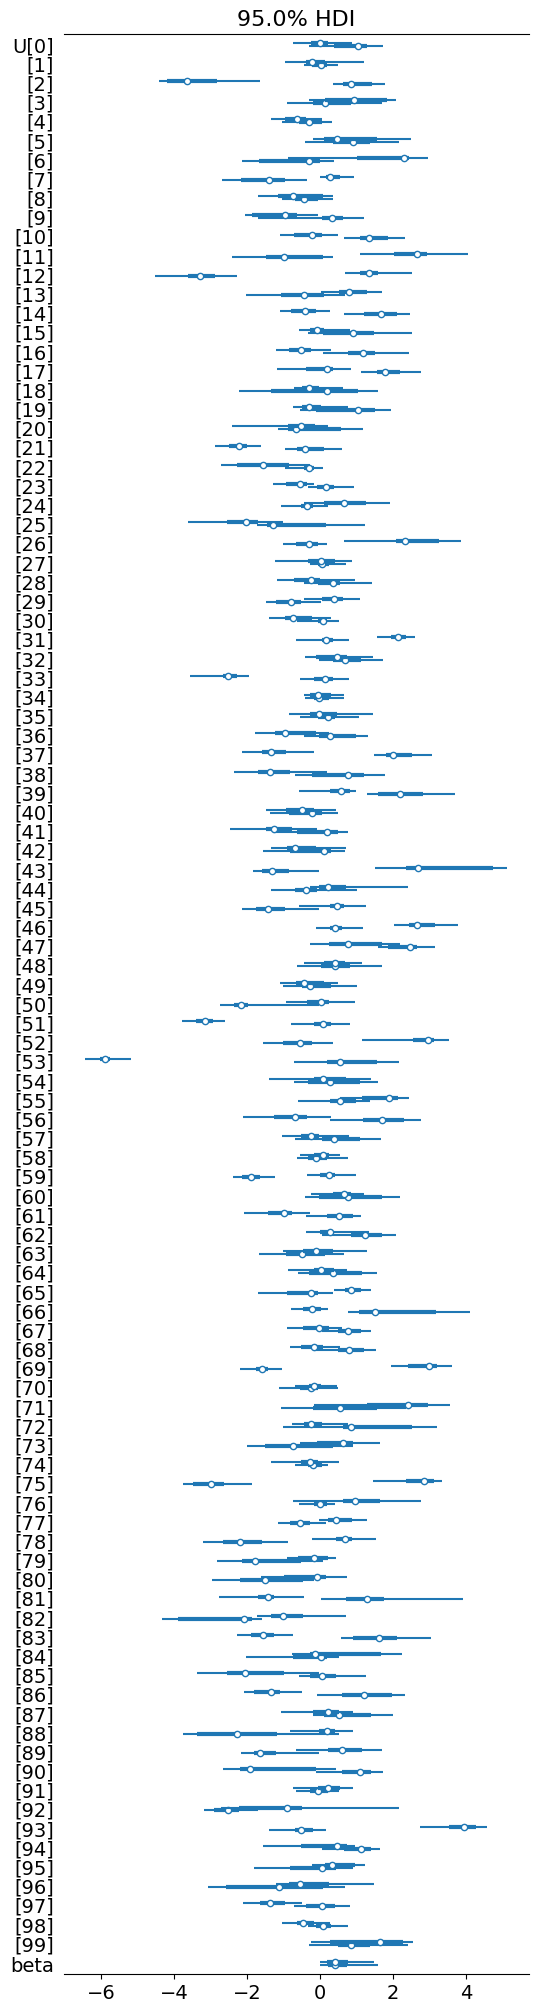

In [360]:
dataset = az.convert_to_inference_data(posterior_dict)

# Calculate Summary Statistics (includes R-hat and ESS)
summary = az.summary(dataset)

# Check for convergence issues across ALL variables
# Filter variables where R-hat is too high
bad_rhat = summary[summary['r_hat'] > 1.1]
# Filter variables where ESS is too low
low_ess = summary[summary['ess_bulk'] < 100]

print("Summary of all 101 variables:")
print(summary.head()) # Shows first few variables

print(f"\nVariables with R-hat > 1.1: {len(bad_rhat)}")
print(f"Variables with Bulk-ESS < 100: {len(low_ess)}")

# Forest Plot (Visual check for all 101 variables at once)
# This plots the credible intervals for all variables.
# If they are wildly inconsistent, it signals convergence issues.
az.plot_forest(dataset, combined=False, hdi_prob=0.95)
plt.savefig("95% HDI")
plt.show()

In [348]:
def flatten_posterior_samples(posterior_dict):
    """
    Convert posterior samples from shape:
      beta: (n_chains, n_draws)
      U:    (n_chains, n_draws, 100)
    into:
      beta_flat: (n_samples,)
      U_flat:    (n_samples, 100)
    """
    beta_flat = posterior_dict["beta"].reshape(-1)
    U_flat = posterior_dict["U"].reshape(-1, posterior_dict["U"].shape[-1])
    return beta_flat, U_flat


In [349]:
def posterior_predictive_prob(X_new, posterior_dict):
    """
    Compute posterior predictive probability:
        p(y=1 | x, data)
    by averaging sigmoid(logit) over all posterior samples.

    Returns:
        mean_prob: shape (n_obs,)
        prob_samples: shape (n_samples, n_obs)
    """
    beta_samples, U_samples = flatten_posterior_samples(posterior_dict)

    n_samples = len(beta_samples)
    n_obs = X_new.shape[0]
    prob_samples = np.zeros((n_samples, n_obs))

    for s in range(n_samples):
        U_s = U_samples[s]                  # shape (100,)
        beta_s = beta_samples[s]            # scalar
        logits = X_new @ U_s * beta_s * np.sum(U_s)
        prob_samples[s] = expit(logits)

    mean_prob = prob_samples.mean(axis=0)
    return mean_prob, prob_samples

In [350]:
def predict_class(X_new, posterior_dict, threshold=0.5):
    """
    Predict binary class labels from posterior predictive mean probabilities.
    """
    mean_prob, prob_samples = posterior_predictive_prob(X_new, posterior_dict)
    y_pred = (mean_prob >= threshold).astype(int)
    return y_pred, mean_prob, prob_samples

In [351]:
def prediction_summary(X_new, posterior_dict, threshold=0.5):
    """
    Return prediction summary including posterior mean probability
    and 95% credible interval for each observation.
    """
    y_pred, mean_prob, prob_samples = predict_class(X_new, posterior_dict, threshold)
    lower = np.percentile(prob_samples, 2.5, axis=0)
    upper = np.percentile(prob_samples, 97.5, axis=0)

    return {
        "pred_class": y_pred,
        "mean_prob": mean_prob,
        "ci_lower_95": lower,
        "ci_upper_95": upper
    }

In [352]:
def classification_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [353]:
pred_result = prediction_summary(X_test, posterior_dict, threshold=0.5)

print("Predicted classes:")
print(pred_result["pred_class"][:10])

print("\nPosterior predictive probabilities:")
print(pred_result["mean_prob"][:10])

print("\n95% credible intervals:")
for i in range(10):
    print(f"Obs {i}: prob={pred_result['mean_prob'][i]:.4f}, "
          f"CI=({pred_result['ci_lower_95'][i]:.4f}, {pred_result['ci_upper_95'][i]:.4f})")

Predicted classes:
[0 1 1 0 1 1 0 1 0 1]

Posterior predictive probabilities:
[0.45578969 0.55438753 0.6071651  0.49695358 0.53768993 0.54610004
 0.3667599  0.5384586  0.45594448 0.57251764]

95% credible intervals:
Obs 0: prob=0.4558, CI=(0.3474, 0.5388)
Obs 1: prob=0.5544, CI=(0.4416, 0.6323)
Obs 2: prob=0.6072, CI=(0.5239, 0.6879)
Obs 3: prob=0.4970, CI=(0.3516, 0.6432)
Obs 4: prob=0.5377, CI=(0.4265, 0.6550)
Obs 5: prob=0.5461, CI=(0.4427, 0.6600)
Obs 6: prob=0.3668, CI=(0.2714, 0.4746)
Obs 7: prob=0.5385, CI=(0.4307, 0.6627)
Obs 8: prob=0.4559, CI=(0.3705, 0.5427)
Obs 9: prob=0.5725, CI=(0.5081, 0.6503)


In [354]:
y_pred = pred_result["pred_class"]
acc = classification_accuracy(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.6300
